# Learned δ_t(S_t) vs Black-Scholes Delta

Each sub-network at step t was trained only on prices that actually occur at t
in a GBM path. We therefore evaluate on simulated test paths — not an arbitrary
grid — bin by S_t, and plot the mean NN delta per bin against the BS delta.

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from pathlib import Path

from src.hedging.hedge_network import HedgeNet
from src.gbm_simulator import GBMParams, simulate

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

In [2]:
# Parameters — must match train_vanilla.py
K, sigma, N, dt = 100.0, 0.2, 30, 1/365
T = N * dt
S0, mu = 100.0, 0.0

RESULTS_DIR = Path('..') / 'results'

network = HedgeNet(N=N, width=20)
network.load_state_dict(torch.load(RESULTS_DIR / 'vanilla_network.pt', weights_only=True))
network.eval()
print('Network loaded.')

Network loaded.


In [3]:
# Simulate test paths (fresh seed)
params = GBMParams(S0=S0, mu=mu, sigma=sigma, T=T, N=N, M=50_000)
paths  = simulate(params, seed=99)   # (50_000, 31)
print('Test paths:', paths.shape)

# Forward pass: get all hedge ratios at once
with torch.no_grad():
    x       = torch.log(paths[:, :-1]).unsqueeze(-1)   # (50_000, 30, 1)
    holding = network(x).numpy()                        # (50_000, 30)

prices = paths[:, :-1].numpy()   # (50_000, 30) — S_t for t=0..29

Test paths: torch.Size([50000, 31])


In [4]:
def bs_delta(S, tau, K, sigma):
    if tau <= 0:
        return (S > K).astype(float)
    d1 = (np.log(S / K) + 0.5 * sigma**2 * tau) / (sigma * np.sqrt(tau))
    return norm.cdf(d1)

def binned_delta(S_vals, delta_vals, n_bins=40):
    """Bin (S, delta) pairs and return bin centres + mean delta per bin."""
    bins   = np.linspace(S_vals.min(), S_vals.max(), n_bins + 1)
    idx    = np.digitize(S_vals, bins) - 1
    idx    = np.clip(idx, 0, n_bins - 1)
    centres, means, stds = [], [], []
    for b in range(n_bins):
        mask = idx == b
        if mask.sum() > 5:
            centres.append(0.5 * (bins[b] + bins[b+1]))
            means.append(delta_vals[mask].mean())
            stds.append(delta_vals[mask].std())
    return np.array(centres), np.array(means), np.array(stds)

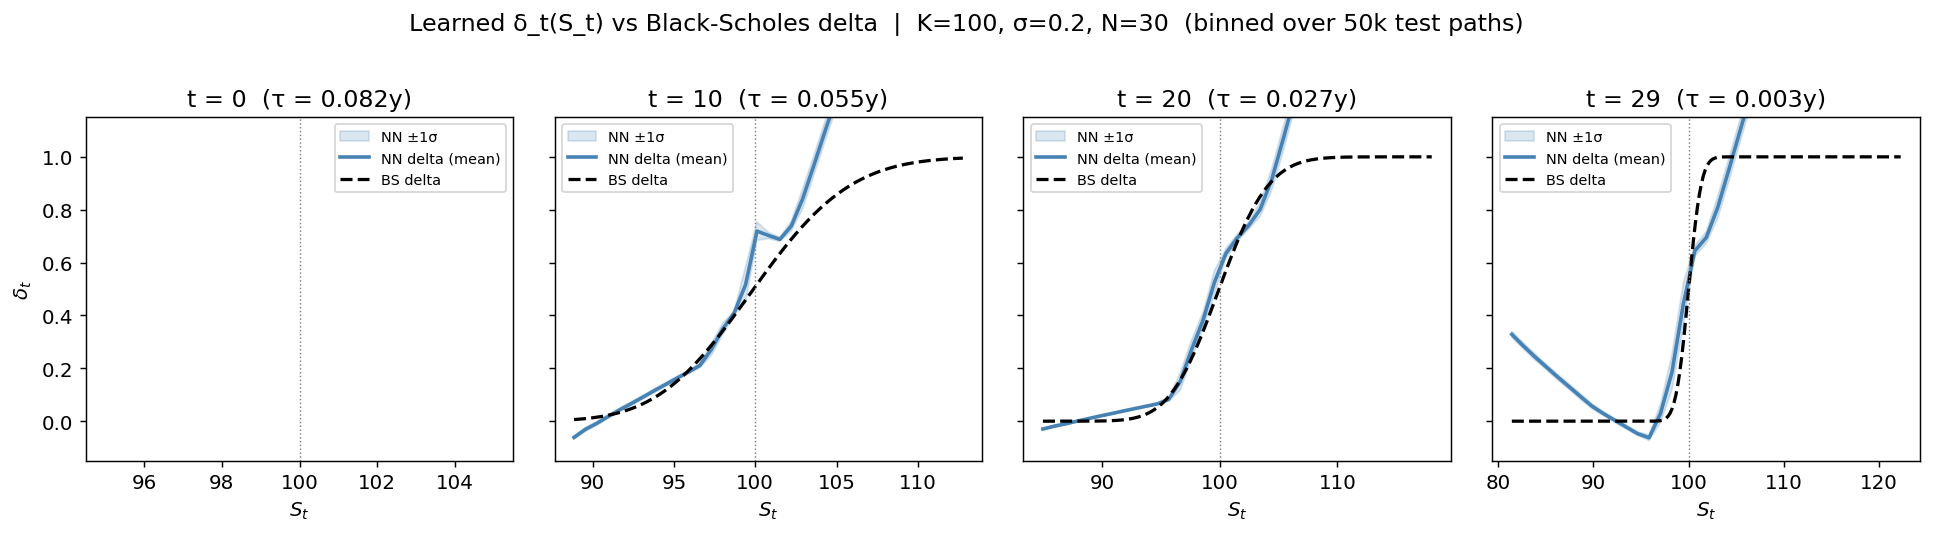

In [5]:
t_indices = [0, 10, 20, 29]

fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=True)

for ax, t_idx in zip(axes, t_indices):
    tau = T - t_idx * dt
    S_t = prices[:, t_idx]
    d_t = holding[:, t_idx]

    # Binned NN delta
    centres, means, stds = binned_delta(S_t, d_t, n_bins=40)

    # BS delta on same range
    S_curve = np.linspace(centres.min(), centres.max(), 200)
    delta_bs = bs_delta(S_curve, tau, K, sigma)

    ax.fill_between(centres, means - stds, means + stds,
                    alpha=0.2, color='steelblue', label='NN ±1σ')
    ax.plot(centres, means,  'steelblue', lw=2,   label='NN delta (mean)')
    ax.plot(S_curve, delta_bs, 'k--',    lw=1.8,  label='BS delta')
    ax.axvline(K, color='grey', lw=0.8, ls=':')

    ax.set_title(f't = {t_idx}  (τ = {tau:.3f}y)')
    ax.set_xlabel('$S_t$')
    if ax is axes[0]:
        ax.set_ylabel('$\\delta_t$')
    ax.legend(fontsize=8)
    ax.set_ylim(-0.15, 1.15)

fig.suptitle('Learned δ_t(S_t) vs Black-Scholes delta  |  K=100, σ=0.2, N=30  (binned over 50k test paths)',
             y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'delta_comparison.png', bbox_inches='tight')
plt.show()